# 🎵 Data Preparation — Audio to Mel Spectrogram
**Dataset:** GTZAN Music Genre Classification  
**Goal:** Convert raw `.wav` files → Mel Spectrogram images (PNG) for CNN input

### Pipeline
```
Raw audio (.wav)  →  Chunking (3s)  →  Mel Spectrogram  →  dB scale  →  PNG image
```

## 1. Install & Import Dependencies

In [1]:
# Run once to install
!pip install librosa numpy matplotlib Pillow torch torchvision tqdm -q

In [2]:
import os
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

print('✅ All libraries imported successfully')
print(f'Librosa version: {librosa.__version__}')
print(f'PyTorch version: {torch.__version__}')

✅ All libraries imported successfully
Librosa version: 0.11.0
PyTorch version: 2.11.0


## 2. Configuration

In [3]:
# ─── Paths ───────────────────────────────────────────────────────
# Kaggle: unzip to this structure
#   Data/genres_original/blues/blues.00000.wav
#   Data/genres_original/jazz/jazz.00000.wav  ...
DATASET_PATH = "Data/genres_original"     
OUTPUT_PATH  = "Data/mel_spectrograms"     
CSV_PATH     = "Data/features_30_sec.csv"  # for baseline (Random Forest)

# ─── Audio params ─────────────────────────────────────────────────
SR           = 22050   # sample rate (Hz)
DURATION     = 3.0     # chunk length in seconds
OVERLAP      = 0.0     # overlap between chunks (0 = no overlap)

# ─── Spectrogram params ────────────────────────────────────────────
N_FFT        = 2048    # FFT window size
HOP_LENGTH   = 512     # frames between windows
N_MELS       = 128     # number of mel frequency bins

# ─── Output image size ─────────────────────────────────────────────
IMG_SIZE     = (224, 224)  # standard CNN input size

# ─── Train/Val/Test split ──────────────────────────────────────────
TRAIN_RATIO  = 0.8
VAL_RATIO    = 0.1
TEST_RATIO   = 0.1
BATCH_SIZE   = 32
RANDOM_SEED  = 42

print('✅ Config set')
print(f'   Chunk duration : {DURATION}s')
print(f'   Mel bins       : {N_MELS}')
print(f'   Output size    : {IMG_SIZE}')

✅ Config set
   Chunk duration : 3.0s
   Mel bins       : 128
   Output size    : (224, 224)


## 3. Explore the Dataset

In [4]:
# Check folder structure and count files
genres = sorted([d for d in os.listdir(DATASET_PATH)
                 if os.path.isdir(os.path.join(DATASET_PATH, d))])

print(f'Found {len(genres)} genres:')
total = 0
for g in genres:
    files = list(Path(DATASET_PATH, g).glob('*.wav'))
    total += len(files)
    print(f'  {g:<15} → {len(files)} files')
print(f'\nTotal audio files: {total}')

Found 10 genres:
  blues           → 100 files
  classical       → 100 files
  country         → 100 files
  disco           → 100 files
  hiphop          → 100 files
  jazz            → 100 files
  metal           → 100 files
  pop             → 100 files
  reggae          → 100 files
  rock            → 100 files

Total audio files: 1000


File      : blues.00093.wav
Duration  : 30.01s
Sample rate: 22050 Hz
Samples   : 661794


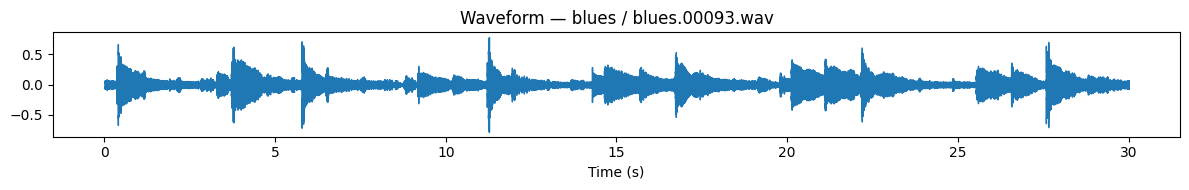

In [5]:
# Listen to and visualise one example
example_genre = genres[0]
example_file  = list(Path(DATASET_PATH, example_genre).glob('*.wav'))[0]

y, sr = librosa.load(example_file, sr=SR, mono=True)

print(f'File      : {example_file.name}')
print(f'Duration  : {len(y)/sr:.2f}s')
print(f'Sample rate: {sr} Hz')
print(f'Samples   : {len(y)}')

# Plot waveform
fig, ax = plt.subplots(figsize=(12, 2))
librosa.display.waveshow(y, sr=sr, ax=ax)
ax.set_title(f'Waveform — {example_genre} / {example_file.name}')
ax.set_xlabel('Time (s)')
plt.tight_layout()
plt.show()

## 4. Audio → Mel Spectrogram (Step by Step)

STFT shape      : (1025, 130)   (freq_bins × time_frames)
Mel shape       : (128, 130)   (128 mel_bins × time_frames)
Mel dB range    : -80.0 to 0.0 dB


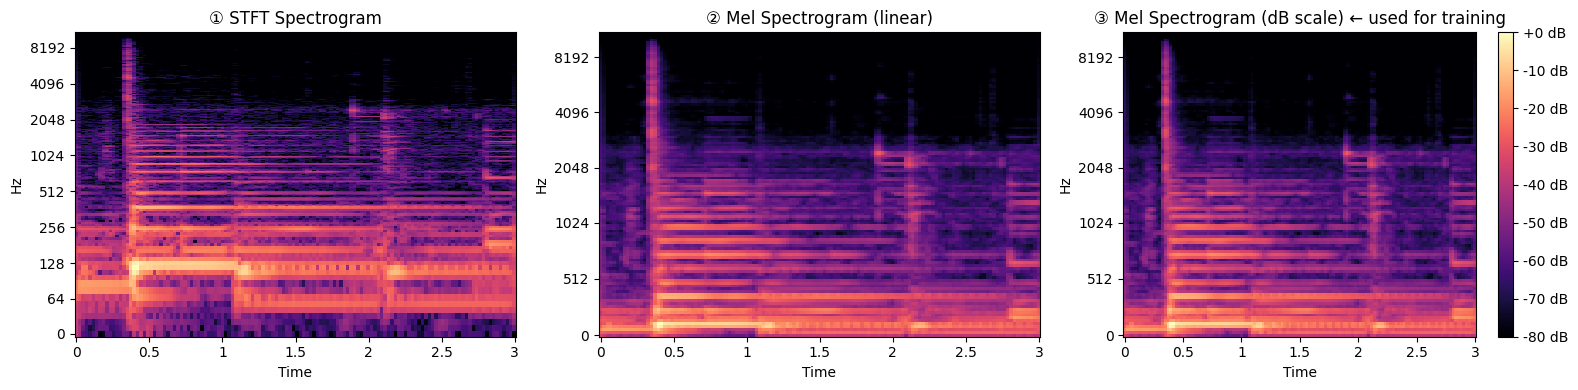

In [6]:
# Use first 3 seconds as example chunk
chunk_len = int(DURATION * SR)
chunk     = y[:chunk_len]

# ── Step 1: STFT → power spectrogram ─────────────────────────────
stft   = np.abs(librosa.stft(chunk, n_fft=N_FFT, hop_length=HOP_LENGTH))
power  = stft ** 2

# ── Step 2: Mel filterbank mapping ───────────────────────────────
mel    = librosa.feature.melspectrogram(
    y=chunk, sr=SR,
    n_fft=N_FFT,
    hop_length=HOP_LENGTH,
    n_mels=N_MELS
)

# ── Step 3: Convert to dB (log scale) ────────────────────────────
mel_db = librosa.power_to_db(mel, ref=np.max)

print(f'STFT shape      : {stft.shape}   (freq_bins × time_frames)')
print(f'Mel shape       : {mel.shape}   ({N_MELS} mel_bins × time_frames)')
print(f'Mel dB range    : {mel_db.min():.1f} to {mel_db.max():.1f} dB')

# ── Visualise all 3 stages ────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

librosa.display.specshow(librosa.amplitude_to_db(stft, ref=np.max),
    sr=SR, hop_length=HOP_LENGTH, x_axis='time', y_axis='log', ax=axes[0])
axes[0].set_title('① STFT Spectrogram')

librosa.display.specshow(librosa.power_to_db(mel, ref=np.max),
    sr=SR, hop_length=HOP_LENGTH, x_axis='time', y_axis='mel', ax=axes[1])
axes[1].set_title('② Mel Spectrogram (linear)')

img = librosa.display.specshow(mel_db,
    sr=SR, hop_length=HOP_LENGTH, x_axis='time', y_axis='mel', ax=axes[2])
axes[2].set_title('③ Mel Spectrogram (dB scale) ← used for training')
fig.colorbar(img, ax=axes[2], format='%+2.0f dB')

plt.tight_layout()
plt.show()

## 5. Compare Mel Spectrograms Across Genres

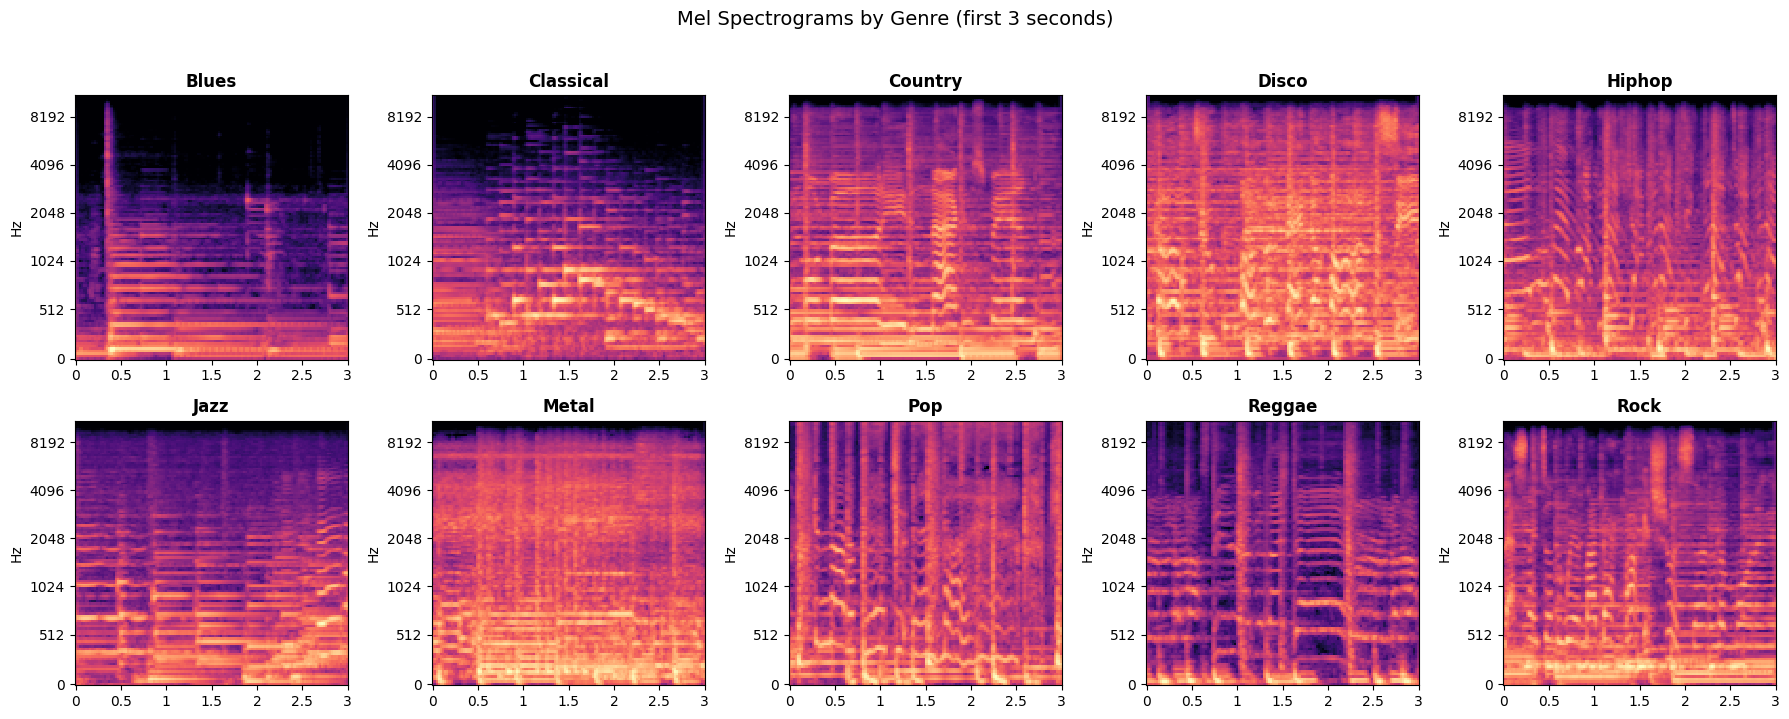

In [7]:
fig, axes = plt.subplots(2, 5, figsize=(18, 7))
axes = axes.flatten()

for i, genre in enumerate(genres):
    wav_files = list(Path(DATASET_PATH, genre).glob('*.wav'))
    if not wav_files:
        continue
    y_g, _ = librosa.load(wav_files[0], sr=SR, duration=DURATION, mono=True)
    mel_g   = librosa.feature.melspectrogram(y=y_g, sr=SR, n_fft=N_FFT,
                                               hop_length=HOP_LENGTH, n_mels=N_MELS)
    mel_db_g = librosa.power_to_db(mel_g, ref=np.max)
    librosa.display.specshow(mel_db_g, sr=SR, hop_length=HOP_LENGTH,
                              x_axis='time', y_axis='mel', ax=axes[i])
    axes[i].set_title(genre.capitalize(), fontweight='bold')
    axes[i].set_xlabel('')

# Hide unused subplots
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Mel Spectrograms by Genre (first 3 seconds)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 6. Convert All Audio → PNG Images

In [8]:
def save_mel_image(y, sr, output_path):
    """
    Convert a numpy audio array to a Mel Spectrogram PNG.
    Saves WITHOUT axes/borders — pure image for CNN.
    """
    mel    = librosa.feature.melspectrogram(
        y=y, sr=sr,
        n_fft=N_FFT,
        hop_length=HOP_LENGTH,
        n_mels=N_MELS
    )
    mel_db = librosa.power_to_db(mel, ref=np.max)

    # Normalise to [0, 255] for image saving
    mel_norm = ((mel_db - mel_db.min()) /
                (mel_db.max() - mel_db.min()) * 255).astype(np.uint8)

    # Save using matplotlib (preserves colormap viridis)
    fig, ax = plt.subplots(figsize=(2.24, 2.24), dpi=100)
    ax.imshow(mel_norm, aspect='auto', origin='lower', cmap='viridis')
    ax.axis('off')
    plt.tight_layout(pad=0)
    fig.savefig(output_path, bbox_inches='tight', pad_inches=0)
    plt.close(fig)


def process_all_genres():
    chunk_len  = int(DURATION * SR)
    hop_chunks = int(chunk_len * (1 - OVERLAP))
    total_imgs = 0
    skipped    = 0

    for genre in genres:
        out_dir = Path(OUTPUT_PATH) / genre
        out_dir.mkdir(parents=True, exist_ok=True)

        wav_files = list(Path(DATASET_PATH, genre).glob('*.wav'))

        for wav_file in tqdm(wav_files, desc=f'{genre:<15}'):
            try:
                y_full, _ = librosa.load(wav_file, sr=SR, mono=True)
            except Exception as e:
                print(f'⚠️  Could not load {wav_file.name}: {e}')
                skipped += 1
                continue

            # Slide window through the audio
            starts = range(0, len(y_full) - chunk_len + 1, hop_chunks)
            for idx, start in enumerate(starts):
                chunk    = y_full[start : start + chunk_len]
                out_file = out_dir / f'{wav_file.stem}_chunk{idx:02d}.png'
                save_mel_image(chunk, SR, out_file)
                total_imgs += 1

    print(f'\n✅ Done!')
    print(f'   Total images created : {total_imgs}')
    print(f'   Files skipped        : {skipped}')
    print(f'   Saved to             : {OUTPUT_PATH}/')

process_all_genres()

jazz           :  46%|████▌     | 46/100 [00:04<00:06,  8.97it/s]

⚠️  Could not load jazz.00054.wav: 


rock           : 100%|██████████| 100/100 [00:10<00:00,  9.61it/s]


✅ Done!
   Total images created : 9981
   Files skipped        : 1
   Saved to             : Data/mel_spectrograms/


## 7. Verify Output

In [9]:
# Count images per genre
print('Images per genre:')
grand_total = 0
for genre in genres:
    imgs = list(Path(OUTPUT_PATH, genre).glob('*.png'))
    grand_total += len(imgs)
    print(f'  {genre:<15} → {len(imgs)} images')
print(f'\nTotal: {grand_total} images')

Images per genre:
  blues           → 1000 images
  classical       → 998 images
  country         → 997 images
  disco           → 999 images
  hiphop          → 998 images
  jazz            → 990 images
  metal           → 1000 images
  pop             → 1000 images
  reggae          → 1000 images
  rock            → 999 images

Total: 9981 images


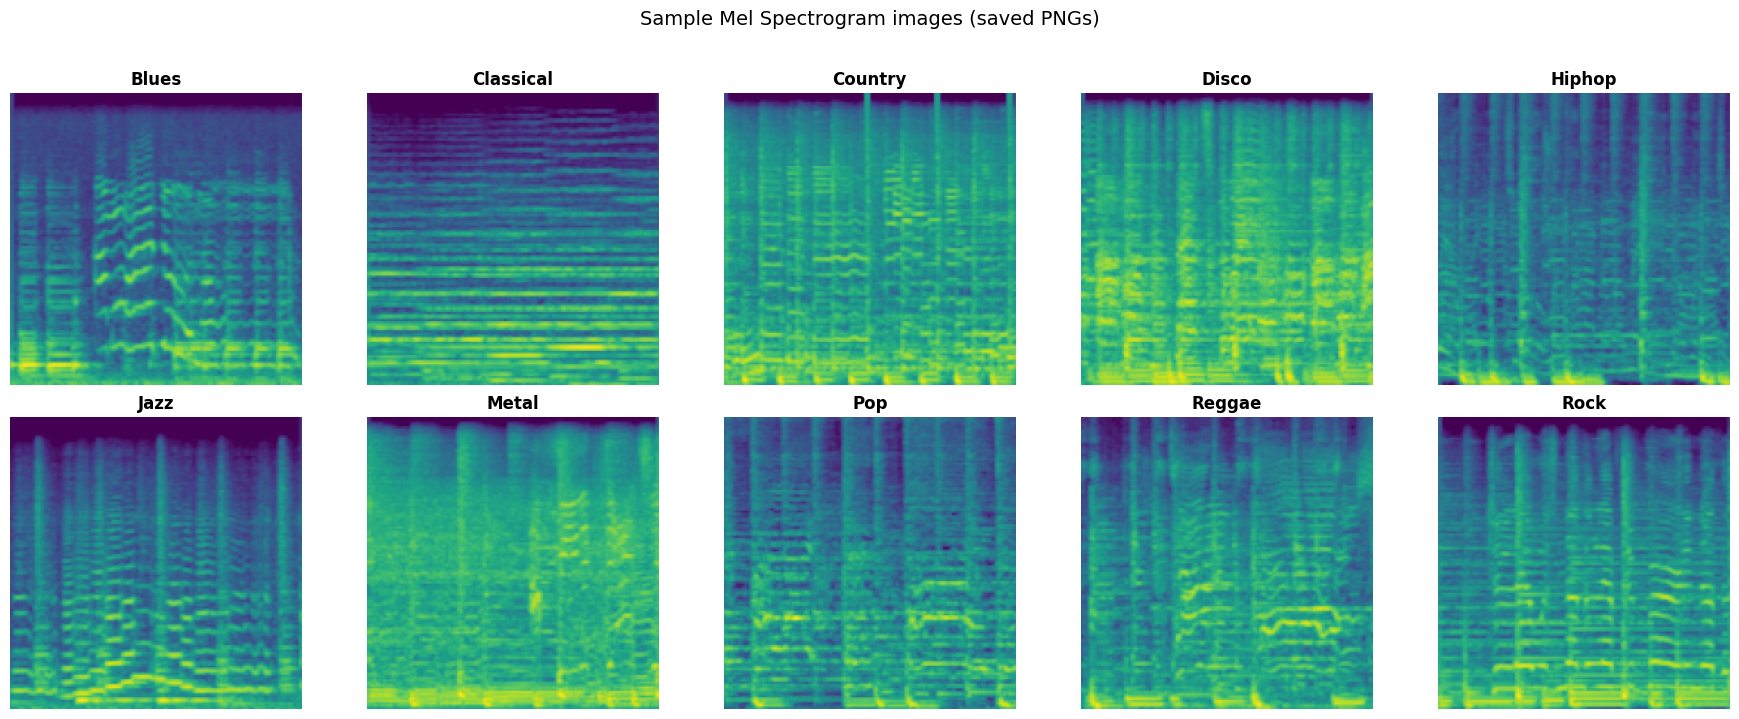

In [10]:
# Preview a grid of saved images
fig, axes = plt.subplots(2, 5, figsize=(18, 7))
axes = axes.flatten()

for i, genre in enumerate(genres):
    imgs = list(Path(OUTPUT_PATH, genre).glob('*.png'))
    if not imgs:
        continue
    img = Image.open(imgs[0]).resize(IMG_SIZE)
    axes[i].imshow(img)
    axes[i].set_title(genre.capitalize(), fontweight='bold')
    axes[i].axis('off')

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Sample Mel Spectrogram images (saved PNGs)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 8. PyTorch DataLoader

In [11]:
torch.manual_seed(RANDOM_SEED)

transform = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.ToTensor(),                        # [0,255] → [0,1]
    transforms.Normalize(mean=[0.5, 0.5, 0.5],   # normalise to [-1,1]
                         std=[0.5, 0.5, 0.5])
])

# ImageFolder auto-labels using subfolder names
full_dataset = datasets.ImageFolder(OUTPUT_PATH, transform=transform)

# Train / Val / Test split
n        = len(full_dataset)
n_train  = int(n * TRAIN_RATIO)
n_val    = int(n * VAL_RATIO)
n_test   = n - n_train - n_val

train_ds, val_ds, test_ds = random_split(
    full_dataset, [n_train, n_val, n_test],
    generator=torch.Generator().manual_seed(RANDOM_SEED)
)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f'Classes  : {full_dataset.classes}')
print(f'Total    : {n}')
print(f'Train    : {n_train}  ({TRAIN_RATIO*100:.0f}%)')
print(f'Val      : {n_val}    ({VAL_RATIO*100:.0f}%)')
print(f'Test     : {n_test}   ({TEST_RATIO*100:.0f}%)')

Classes  : ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']
Total    : 9981
Train    : 7984  (80%)
Val      : 998    (10%)
Test     : 999   (10%)


Batch image shape : torch.Size([32, 3, 224, 224])  (B × C × H × W)
Batch label shape : torch.Size([32])
Label examples    : ['reggae', 'disco', 'classical', 'blues', 'jazz', 'disco', 'rock', 'disco']


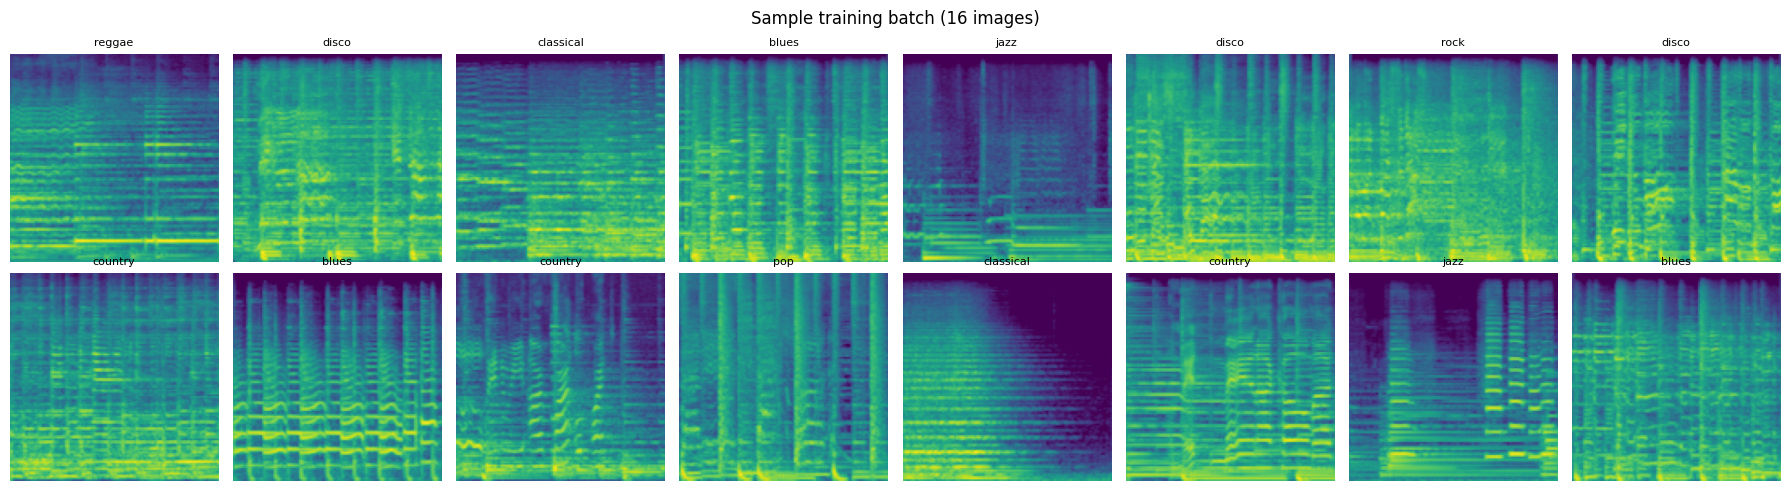

In [12]:
# Sanity check: visualise one batch
images, labels = next(iter(train_loader))
print(f'Batch image shape : {images.shape}  (B × C × H × W)')
print(f'Batch label shape : {labels.shape}')
print(f'Label examples    : {[full_dataset.classes[l] for l in labels[:8].tolist()]}')

# Unnormalize for display
def unnorm(t):
    return (t * 0.5 + 0.5).clamp(0, 1)

fig, axes = plt.subplots(2, 8, figsize=(18, 5))
for i in range(8):
    img = unnorm(images[i]).permute(1, 2, 0).numpy()
    axes[0, i].imshow(img)
    axes[0, i].set_title(full_dataset.classes[labels[i]], fontsize=8)
    axes[0, i].axis('off')
    if i + 8 < len(images):
        img2 = unnorm(images[i+8]).permute(1, 2, 0).numpy()
        axes[1, i].imshow(img2)
        axes[1, i].set_title(full_dataset.classes[labels[i+8]], fontsize=8)
        axes[1, i].axis('off')

plt.suptitle('Sample training batch (16 images)', fontsize=12)
plt.tight_layout()
plt.show()

## 9. (Optional) Data Augmentation for Training

In [13]:
# Augmented transform for training only
# Helps model generalise — common for spectrogram images
train_transform = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.RandomHorizontalFlip(p=0.3),         # flip time axis
    transforms.RandomErasing(p=0.2, scale=(0.02, 0.1)),  # freq/time masking
    transforms.ColorJitter(brightness=0.2, contrast=0.2), # amplitude variation
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5],
                         std=[0.5, 0.5, 0.5])
])

val_test_transform = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5],
                         std=[0.5, 0.5, 0.5])
])

# Re-build datasets with separate transforms
full_dataset_aug = datasets.ImageFolder(OUTPUT_PATH, transform=train_transform)
full_dataset_val = datasets.ImageFolder(OUTPUT_PATH, transform=val_test_transform)

train_ds_aug = torch.utils.data.Subset(full_dataset_aug, train_ds.indices)
val_ds_aug   = torch.utils.data.Subset(full_dataset_val, val_ds.indices)
test_ds_aug  = torch.utils.data.Subset(full_dataset_val, test_ds.indices)

train_loader_aug = DataLoader(train_ds_aug, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
val_loader_aug   = DataLoader(val_ds_aug,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader_aug  = DataLoader(test_ds_aug,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print('✅ Augmented DataLoaders ready')
print('   Use train_loader_aug for training, val_loader_aug / test_loader_aug for evaluation')

✅ Augmented DataLoaders ready
   Use train_loader_aug for training, val_loader_aug / test_loader_aug for evaluation


## 10. Summary & Next Steps

```
✅ Done — what you have now:

Data/
  mel_spectrograms/
    blues/     blues.00000_chunk00.png  blues.00000_chunk01.png  ...
    classical/ ...
    country/   ...
    ...
```

| Variable | Description |
|---|---|
| `train_loader` | Training DataLoader (no augmentation) |
| `val_loader` | Validation DataLoader |
| `test_loader` | Test DataLoader |
| `train_loader_aug` | Training DataLoader (with augmentation) |
| `full_dataset.classes` | List of 10 genre names |

### Next notebook: Baseline & Evaluation
- Random Forest on `features_30_sec.csv` (quick baseline)
- Simple 2D CNN on mel spectrogram images
- Metrics: F1-score + Confusion Matrix